# Adversarial Training Experiment (FGSM) — M7md's Branch

This notebook studies the effect of **adversarial training** (FGSM-based)
on generalization and robustness of the overfitting MLP baseline
trained on CIFAR-10.

### Method
- **FGSM** (Fast Gradient Sign Method) generates adversarial examples during training
- Combined loss: **50 % clean** + **50 % adversarial**
- Epsilon = **0.03** (perturbation magnitude)

### Evaluation
- Model is evaluated on **both clean and adversarial** test sets

### Controlled Setup (identical to all other team experiments)
| Parameter | Value |
|-----------|-------|
| Model | MLP [1024, 512, 256] with ReLU |
| Optimizer | SGD, lr = 0.01 |
| Epochs | 50 |
| Batch size | 128 |
| Train / Val / Test | 15 000 / 5 000 / 10 000 |
| Seed | 42 |

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import numpy as np

# Set seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

## Model Definition

In [2]:
class AblationMLP(nn.Module):
    def __init__(self, use_dropout=False, use_batchnorm=False,
                 dropout_p=0.5, hidden_sizes=None):
        super(AblationMLP, self).__init__()
        if hidden_sizes is None:
            hidden_sizes = [1024, 512, 256]

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(3072, hidden_sizes[0])
        self.bn1 = nn.BatchNorm1d(hidden_sizes[0]) if use_batchnorm else None
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_p) if use_dropout else None

        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.bn2 = nn.BatchNorm1d(hidden_sizes[1]) if use_batchnorm else None
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_p) if use_dropout else None

        self.fc3 = nn.Linear(hidden_sizes[1], hidden_sizes[2])
        self.bn3 = nn.BatchNorm1d(hidden_sizes[2]) if use_batchnorm else None
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(dropout_p) if use_dropout else None

        self.fc4 = nn.Linear(hidden_sizes[2], 10)

        self.use_dropout = use_dropout
        self.use_batchnorm = use_batchnorm

    def forward(self, x):
        x = self.flatten(x)

        x = self.fc1(x)
        if self.use_batchnorm:
            x = self.bn1(x)
        x = self.relu1(x)
        if self.use_dropout:
            x = self.dropout1(x)

        x = self.fc2(x)
        if self.use_batchnorm:
            x = self.bn2(x)
        x = self.relu2(x)
        if self.use_dropout:
            x = self.dropout2(x)

        x = self.fc3(x)
        if self.use_batchnorm:
            x = self.bn3(x)
        x = self.relu3(x)
        if self.use_dropout:
            x = self.dropout3(x)

        x = self.fc4(x)
        return x

## FGSM Attack & Helper Functions

In [3]:
def fgsm_attack(images, epsilon, data_grad):
    """
    Generate adversarial examples using FGSM.
    x_adv = x + epsilon * sign(grad_x L(theta, x, y))
    """
    sign_data_grad = data_grad.sign()
    perturbed = images + epsilon * sign_data_grad
    return perturbed


def evaluate(model, dataloader, device):
    """Compute accuracy on a dataloader."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    model.train()
    return 100 * correct / total


def evaluate_adversarial(model, dataloader, loss_fn, device, epsilon):
    """Compute accuracy on adversarial examples generated from a dataloader."""
    model.eval()
    correct = 0
    total = 0
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        images.requires_grad = True
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        model.zero_grad()
        loss.backward()
        data_grad = images.grad.data
        perturbed = fgsm_attack(images, epsilon, data_grad)
        adv_outputs = model(perturbed)
        _, predicted = torch.max(adv_outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    model.train()
    return 100 * correct / total


def compute_loss(model, dataloader, loss_fn, device):
    """Compute average loss on a dataloader."""
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            total_loss += loss.item()
    model.train()
    return total_loss / len(dataloader)


def train_epoch_adversarial(model, train_loader, optimizer, loss_fn,
                            device, epsilon):
    """
    Adversarial training for one epoch.
    Combined loss = 0.5 * clean_loss + 0.5 * adv_loss
    """
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Clean forward pass
        images_clean = images.detach().requires_grad_(True)
        outputs_clean = model(images_clean)
        loss_clean = loss_fn(outputs_clean, labels)

        # Generate adversarial examples via FGSM
        model.zero_grad()
        loss_clean.backward(retain_graph=True)
        data_grad = images_clean.grad.data
        images_adv = fgsm_attack(images_clean, epsilon, data_grad).detach()

        # Adversarial forward pass
        outputs_adv = model(images_adv)
        loss_adv = loss_fn(outputs_adv, labels)

        # Combined loss
        combined_loss = 0.5 * loss_clean + 0.5 * loss_adv

        optimizer.zero_grad()
        combined_loss.backward()
        optimizer.step()

        total_loss += combined_loss.item()
    return total_loss / len(train_loader)

## Data Loading

In [4]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

full_train_dataset = datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)
full_test_dataset  = datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform)

# 3-Way Split (Golden Rule)
torch.manual_seed(SEED)
subset_size = 20000
remaining_size = 50000 - subset_size
subset_train, _ = torch.utils.data.random_split(
    full_train_dataset, [subset_size, remaining_size],
    generator=torch.Generator().manual_seed(SEED))

train_size = 15000
val_size   = 5000
train_dataset, val_dataset = torch.utils.data.random_split(
    subset_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED))

test_dataset = full_test_dataset

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=128, shuffle=True)
val_loader   = torch.utils.data.DataLoader(
    val_dataset, batch_size=128, shuffle=False)
test_loader  = torch.utils.data.DataLoader(
    test_dataset, batch_size=128, shuffle=False)

print("=" * 80)
print("ADVERSARIAL TRAINING EXPERIMENT (FGSM)")
print("=" * 80)
print(f"Training set size:   {len(train_dataset):,} images")
print(f"Validation set size: {len(val_dataset):,} images")
print(f"Test set size:       {len(test_dataset):,} images")
print(f"Total used:          {len(train_dataset) + len(val_dataset) + len(test_dataset):,} images")
print("=" * 80)

/Users/omar/Documents/uni/DL/project_1/dl_env/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


ADVERSARIAL TRAINING EXPERIMENT (FGSM)
Training set size:   15,000 images
Validation set size: 5,000 images
Test set size:       10,000 images
Total used:          30,000 images


## Model & Optimizer Setup

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
learning_rate = 0.01
max_epochs = 50
EPSILON = 0.03  # FGSM perturbation magnitude

model = AblationMLP(
    use_dropout=False, use_batchnorm=False,
    hidden_sizes=[1024, 512, 256]).to(device)
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()

print(f"Device: {device}")
print(f"Learning Rate: {learning_rate}")
print(f"Max Epochs: {max_epochs}")
print(f"FGSM Epsilon: {EPSILON}")
print(f"Model: Overparameterized MLP [1024, 512, 256] — Adversarial Training")
print(f"Total trainable parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"\nAdversarial Training Method:")
print(f"  - FGSM (Fast Gradient Sign Method)")
print(f"  - Combined loss: 50% clean + 50% adversarial")
print(f"  - Epsilon (perturbation magnitude): {EPSILON}")

Device: cpu
Learning Rate: 0.01
Max Epochs: 50
FGSM Epsilon: 0.03
Model: Overparameterized MLP [1024, 512, 256] — Adversarial Training
Total trainable parameters: 3,805,450

Adversarial Training Method:
  - FGSM (Fast Gradient Sign Method)
  - Combined loss: 50% clean + 50% adversarial
  - Epsilon (perturbation magnitude): 0.03


## Training Loop

In [6]:
train_losses = []
val_losses   = []
train_accuracies = []
val_accuracies   = []

for epoch in range(max_epochs):
    loss = train_epoch_adversarial(
        model, train_loader, optimizer, loss_fn, device, EPSILON)
    train_losses.append(loss)

    train_acc = evaluate(model, train_loader, device)
    val_loss  = compute_loss(model, val_loader, loss_fn, device)
    val_acc   = evaluate(model, val_loader, device)

    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1:2d}/{max_epochs} | Train Loss: {loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

print("\n" + "=" * 80)
print("TRAINING COMPLETED")
print("=" * 80)
print(f"Training finished at epoch: {max_epochs}/{max_epochs}")

Epoch  1/50 | Train Loss: 2.2901 | Val Loss: 2.2278 | Train Acc: 25.55% | Val Acc: 24.14%
Epoch  2/50 | Train Loss: 2.1895 | Val Loss: 2.1147 | Train Acc: 27.11% | Val Acc: 25.64%
Epoch  3/50 | Train Loss: 2.0850 | Val Loss: 2.0153 | Train Acc: 30.34% | Val Acc: 28.32%
Epoch  4/50 | Train Loss: 2.0038 | Val Loss: 1.9412 | Train Acc: 32.08% | Val Acc: 30.04%
Epoch  5/50 | Train Loss: 1.9411 | Val Loss: 1.8821 | Train Acc: 34.15% | Val Acc: 31.82%
Epoch  6/50 | Train Loss: 1.8896 | Val Loss: 1.8399 | Train Acc: 35.98% | Val Acc: 33.40%
Epoch  7/50 | Train Loss: 1.8510 | Val Loss: 1.8030 | Train Acc: 37.95% | Val Acc: 35.08%
Epoch  8/50 | Train Loss: 1.8133 | Val Loss: 1.7638 | Train Acc: 39.55% | Val Acc: 36.92%
Epoch  9/50 | Train Loss: 1.7795 | Val Loss: 1.7318 | Train Acc: 41.16% | Val Acc: 38.38%
Epoch 10/50 | Train Loss: 1.7509 | Val Loss: 1.7106 | Train Acc: 41.80% | Val Acc: 38.34%
Epoch 11/50 | Train Loss: 1.7232 | Val Loss: 1.6816 | Train Acc: 43.39% | Val Acc: 39.48%
Epoch 12/5

## Final Evaluation — Clean AND Adversarial Test Sets

In [7]:
test_acc_clean = evaluate(model, test_loader, device)
test_loss      = compute_loss(model, test_loader, loss_fn, device)
test_acc_adv   = evaluate_adversarial(
    model, test_loader, loss_fn, device, EPSILON)

generalization_gap = train_accuracies[-1] - val_accuracies[-1]

print(f"\nFINAL TEST EVALUATION (After {max_epochs} Epochs):")
print(f"\nFinal Metrics:")
print(f"  Training Accuracy:          {train_accuracies[-1]:.2f}%")
print(f"  Validation Accuracy:        {val_accuracies[-1]:.2f}%")
print(f"  Test Accuracy (Clean):      {test_acc_clean:.2f}%")
print(f"  Test Accuracy (Adversarial): {test_acc_adv:.2f}%")
print(f"\nGeneralization Gap Analysis:")
print(f"  GENERALIZATION GAP (Train Acc - Val Acc): {generalization_gap:.2f}% ← KEY METRIC")
print(f"  (Train Acc - Test Acc Clean): {train_accuracies[-1] - test_acc_clean:.2f}%")
print(f"\nRobustness Analysis:")
print(f"  Clean Test Accuracy:       {test_acc_clean:.2f}%")
print(f"  Adversarial Test Accuracy: {test_acc_adv:.2f}%")
print(f"  Robustness Drop:           {test_acc_clean - test_acc_adv:.2f}%")
print("=" * 80)


FINAL TEST EVALUATION (After 50 Epochs):

Final Metrics:
  Training Accuracy:          70.91%
  Validation Accuracy:        46.22%
  Test Accuracy (Clean):      48.11%
  Test Accuracy (Adversarial): 31.14%

Generalization Gap Analysis:
  GENERALIZATION GAP (Train Acc - Val Acc): 24.69% ← KEY METRIC
  (Train Acc - Test Acc Clean): 22.80%

Robustness Analysis:
  Clean Test Accuracy:       48.11%
  Adversarial Test Accuracy: 31.14%
  Robustness Drop:           16.97%


## Visualization

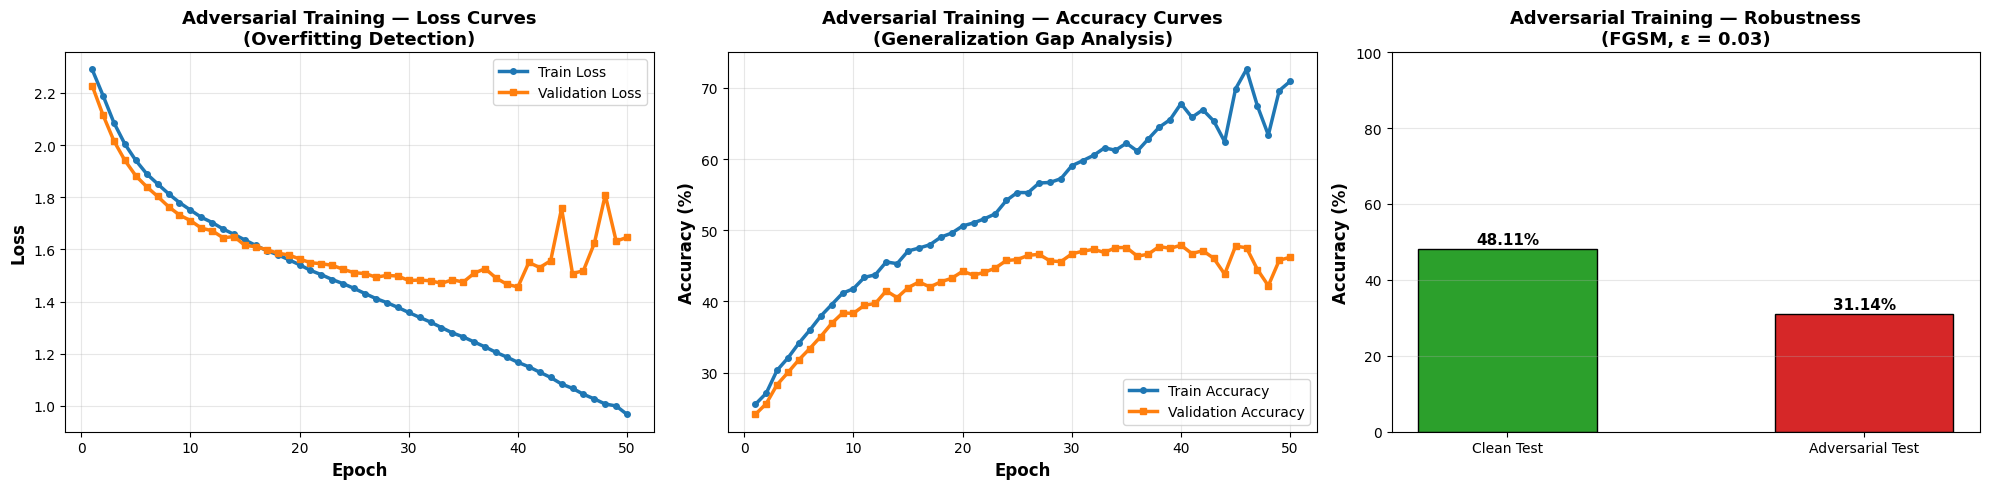


GENERALIZATION GAP SUMMARY (Adversarial Training Experiment)
Final Epoch (50):
  Training Accuracy:          70.91%
  Validation Accuracy:        46.22%
  Test Accuracy (Clean):      48.11%
  Test Accuracy (Adversarial): 31.14%

GENERALIZATION GAP (Train - Val): 24.69% ← KEY METRIC FOR COMPARING REGULARIZATION METHODS

ROBUSTNESS DROP (Clean - Adv): 16.97% ← MEASURES MODEL ROBUSTNESS


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
epochs_range = range(1, max_epochs + 1)

# (a) Loss Curves
ax = axes[0]
ax.plot(epochs_range, train_losses, 'o-',
        label='Train Loss', linewidth=2.5, markersize=4, color='#1f77b4')
ax.plot(epochs_range, val_losses, 's-',
        label='Validation Loss', linewidth=2.5, markersize=4, color='#ff7f0e')
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax.set_title('Adversarial Training — Loss Curves\n(Overfitting Detection)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)

# (b) Accuracy Curves
ax = axes[1]
ax.plot(epochs_range, train_accuracies, 'o-',
        label='Train Accuracy', linewidth=2.5, markersize=4, color='#1f77b4')
ax.plot(epochs_range, val_accuracies, 's-',
        label='Validation Accuracy', linewidth=2.5, markersize=4, color='#ff7f0e')
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Adversarial Training — Accuracy Curves\n(Generalization Gap Analysis)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)

# (c) Robustness Comparison Bar Chart
ax = axes[2]
categories = ['Clean Test', 'Adversarial Test']
values = [test_acc_clean, test_acc_adv]
colors = ['#2ca02c', '#d62728']
bars = ax.bar(categories, values, color=colors, width=0.5, edgecolor='black')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.2f}%', ha='center', va='bottom',
            fontsize=11, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title(f'Adversarial Training — Robustness\n(FGSM, ε = {EPSILON})',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Final Summary
print("\n" + "=" * 80)
print("GENERALIZATION GAP SUMMARY (Adversarial Training Experiment)")
print("=" * 80)
print(f"Final Epoch ({max_epochs}):")
print(f"  Training Accuracy:          {train_accuracies[-1]:.2f}%")
print(f"  Validation Accuracy:        {val_accuracies[-1]:.2f}%")
print(f"  Test Accuracy (Clean):      {test_acc_clean:.2f}%")
print(f"  Test Accuracy (Adversarial): {test_acc_adv:.2f}%")
print(f"\nGENERALIZATION GAP (Train - Val): {generalization_gap:.2f}% ← KEY METRIC FOR COMPARING REGULARIZATION METHODS")
print(f"\nROBUSTNESS DROP (Clean - Adv): {test_acc_clean - test_acc_adv:.2f}% ← MEASURES MODEL ROBUSTNESS")
print("=" * 80)